# Synthetic Identity Events — Dataset Explorer

Visual overview of `files/synthetic_identity_events.json` for the UEBA Risk Model.

In [4]:
! pip install pandas
! pip install numpy
! pip install matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

df = pd.read_csv('/Zero-Day/UEBA/Synthetic_Dataset/synthetic_identity_events.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

C = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3','#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']
print(f'Total records: {len(df)}')
print(f'Unique users: {df["user_id"].nunique()}')
print(f'Anomalous: {df["is_anomalous_ground_truth"].sum()} ({df["is_anomalous_ground_truth"].mean()*100:.1f}%)')

Total records: 3000
Unique users: 15
Anomalous: 251 (8.4%)


## 1. Events per User

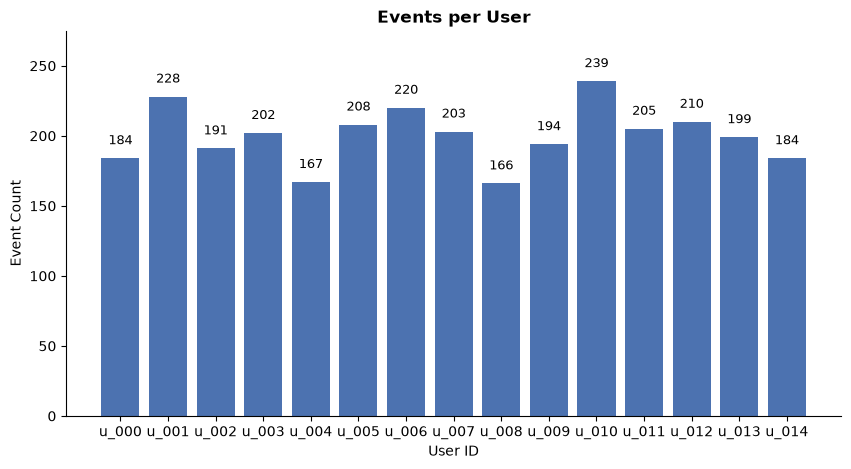

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['user_id'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=C[0])
ax.set_xlabel('User ID'); ax.set_ylabel('Event Count')
ax.set_title('Events per User', fontweight='bold')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10, str(int(b.get_height())), ha='center', fontsize=9)
ax.set_ylim(0, counts.max()*1.15)
ax.spines[['top','right']].set_visible(False)
plt.show()

## 2. Activity Distribution

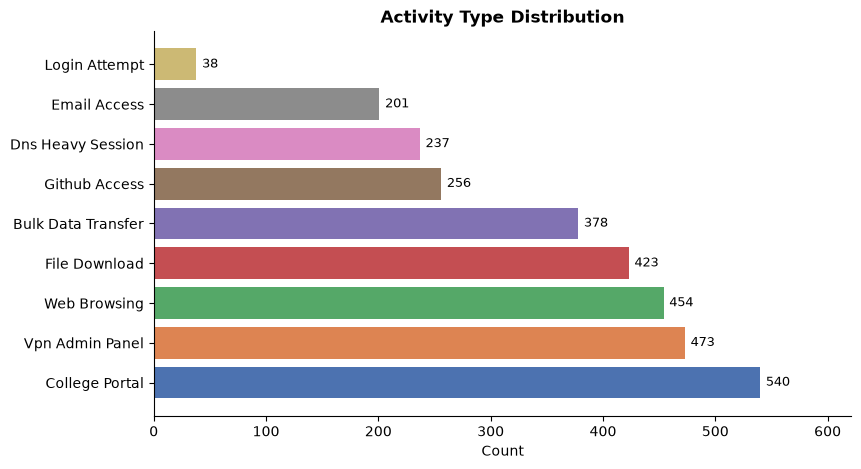

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
counts = df['activity'].value_counts()
b = ax.barh([a.replace('_',' ').title() for a in counts.index], counts.values, color=C)
ax.set_xlabel('Count'); ax.set_title('Activity Type Distribution', fontweight='bold')
for i, c in enumerate(counts.values):
    ax.text(c+5, i, str(c), va='center', fontsize=9)
ax.set_xlim(0, counts.max()*1.15)
ax.spines[['top','right']].set_visible(False)
plt.show()

## 3. Anomaly Breakdown

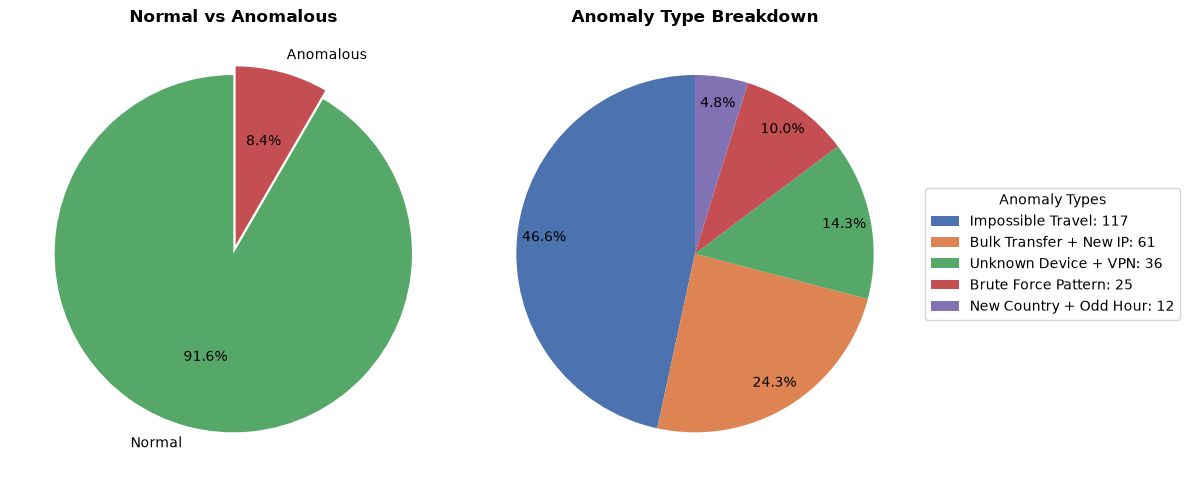

In [8]:
anom = df['is_anomalous_ground_truth'].sum()
norm = len(df) - anom
atypes = df.dropna(subset=['anomaly_type'])['anomaly_type'].value_counts()
atype_labels = {
    'impossible_travel': 'Impossible Travel', 'new_country_odd_hour': 'New Country + Odd Hour',
    'bulk_transfer_new_ip': 'Bulk Transfer + New IP', 'unknown_device_vpn': 'Unknown Device + VPN',
    'brute_force_pattern': 'Brute Force Pattern'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
ax1.pie([norm, anom], labels=['Normal', 'Anomalous'], autopct='%1.1f%%',
        colors=['#55A868', '#C44E52'], startangle=90, explode=(0, 0.05))
ax1.set_title('Normal vs Anomalous', fontweight='bold')

wedges, _, autotexts = ax2.pie(atypes.values, labels=None, autopct='%1.1f%%',
                               colors=C[:len(atypes)], startangle=90, pctdistance=0.85)
ax2.set_title('Anomaly Type Breakdown', fontweight='bold')
ax2.legend(wedges, [f'{atype_labels[k]}: {v}' for k,v in atypes.items()],
          title='Anomaly Types', loc='center left', bbox_to_anchor=(1,0,0.5,1))
plt.tight_layout(); plt.show()

## 4. Events by City

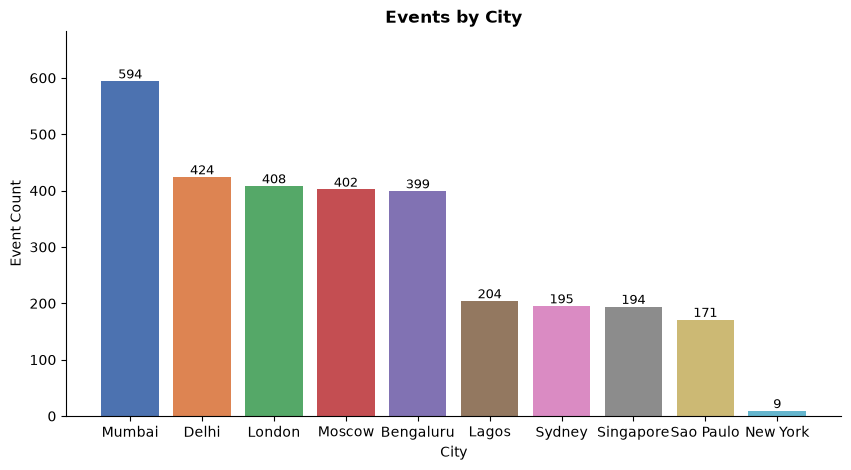

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['geo_city'].value_counts()
b = ax.bar(counts.index, counts.values, color=C[:len(counts)])
ax.set_xlabel('City'); ax.set_ylabel('Event Count')
ax.set_title('Events by City', fontweight='bold')
for bar in b:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(int(bar.get_height())), ha='center', fontsize=9)
ax.set_ylim(0, counts.max()*1.15)
ax.spines[['top','right']].set_visible(False)
plt.show()

## 5. VPN & Login Status

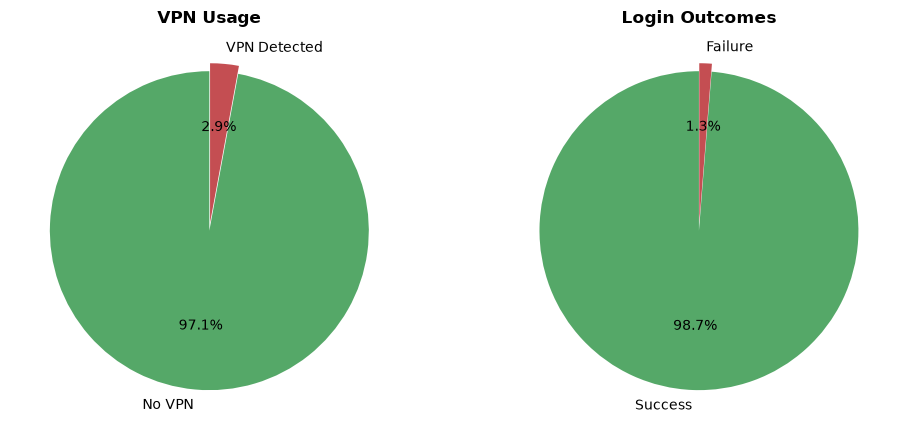

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
ax1.pie(df['vpn_detected'].value_counts(), labels=['No VPN', 'VPN Detected'], autopct='%1.1f%%',
        colors=['#55A868', '#C44E52'], startangle=90, explode=(0, 0.05))
ax1.set_title('VPN Usage', fontweight='bold')
ax2.pie(df['login_success'].value_counts(), labels=['Success', 'Failure'], autopct='%1.1f%%',
        colors=['#55A868', '#C44E52'], startangle=90, explode=(0, 0.05))
ax2.set_title('Login Outcomes', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. OS Distribution

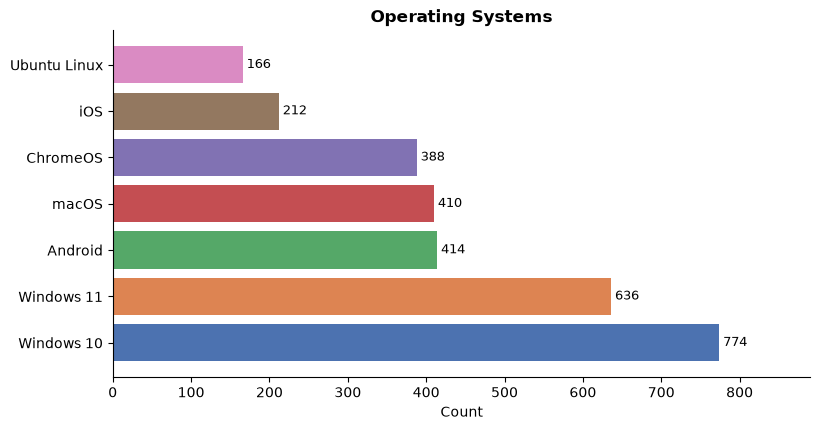

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
counts = df['os'].value_counts()
b = ax.barh(counts.index, counts.values, color=C[:len(counts)])
ax.set_xlabel('Count'); ax.set_title('Operating Systems', fontweight='bold')
for i, c in enumerate(counts.values):
    ax.text(c+5, i, str(c), va='center', fontsize=9)
ax.set_xlim(0, counts.max()*1.15)
ax.spines[['top','right']].set_visible(False)
plt.show()

## 7. Timeline (Events per Hour)

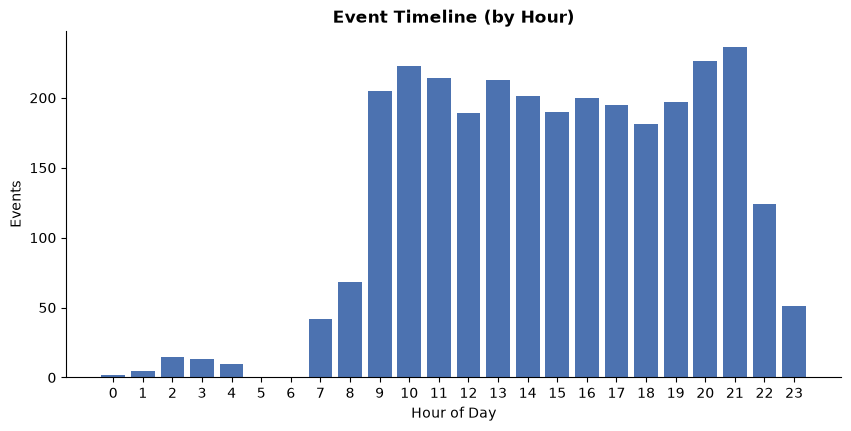

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
hour_counts = df['hour'].value_counts().sort_index()
ax.bar(hour_counts.index, hour_counts.values, color=C[0])
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Events')
ax.set_title('Event Timeline (by Hour)', fontweight='bold')
ax.set_xticks(range(24))
ax.spines[['top','right']].set_visible(False)
plt.show()

## 8. Impossible Travel Speeds

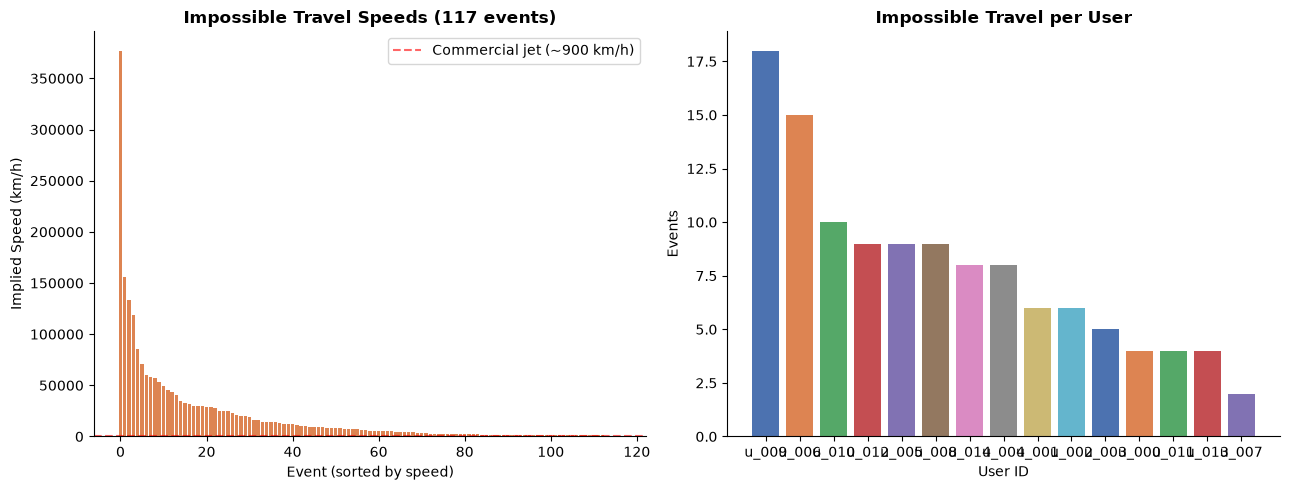

In [13]:
imp = df.dropna(subset=['implied_speed_kmh'])
if len(imp):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    speeds = imp['implied_speed_kmh'].sort_values(ascending=False)
    ax1.bar(range(len(speeds)), speeds.values, color=C[1])
    ax1.set_xlabel('Event (sorted by speed)'); ax1.set_ylabel('Implied Speed (km/h)')
    ax1.set_title(f'Impossible Travel Speeds ({len(imp)} events)', fontweight='bold')
    ax1.spines[['top','right']].set_visible(False)
    ax1.axhline(y=900, color='red', linestyle='--', alpha=0.6, label='Commercial jet (~900 km/h)')
    ax1.legend()
    imp_users = imp['user_id'].value_counts()
    ax2.bar(imp_users.index, imp_users.values, color=C[:len(imp_users)])
    ax2.set_xlabel('User ID'); ax2.set_ylabel('Events')
    ax2.set_title('Impossible Travel per User', fontweight='bold')
    ax2.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.show()

## 9. Anomaly Types by Activity

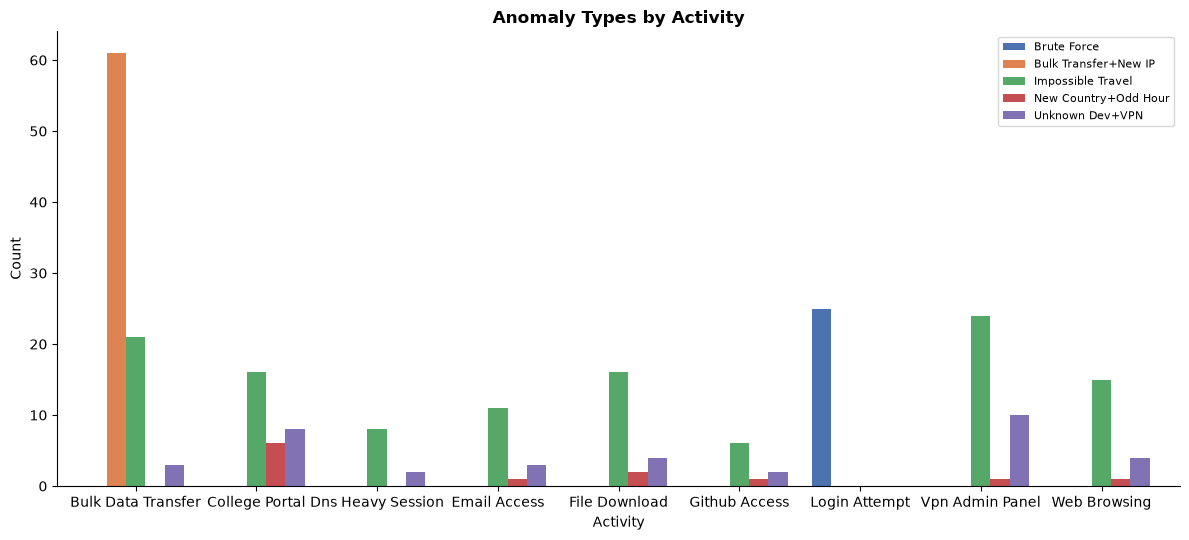

In [14]:
ct = pd.crosstab(df['activity'], df['anomaly_type'])
atype_map = {'impossible_travel': 'Impossible Travel', 'new_country_odd_hour': 'New Country+Odd Hour',
             'bulk_transfer_new_ip': 'Bulk Transfer+New IP', 'unknown_device_vpn': 'Unknown Dev+VPN',
             'brute_force_pattern': 'Brute Force'}
ct = ct.rename(columns=atype_map)
fig, ax = plt.subplots(figsize=(12, 5.5))
ct.plot(kind='bar', ax=ax, color=C[:len(ct.columns)], width=0.8)
ax.set_xlabel('Activity'); ax.set_ylabel('Count')
ax.set_title('Anomaly Types by Activity', fontweight='bold')
ax.set_xticklabels([a.replace('_',' ').title() for a in ct.index], rotation=0)
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 10. Timezone Analysis (User Local Hour)

Each user has a `user_home_tz` based on their most common city. `user_local_hour` converts event timestamps to the user's home timezone.
This enables detecting logins at odd hours in the user's local time — not just raw UTC.

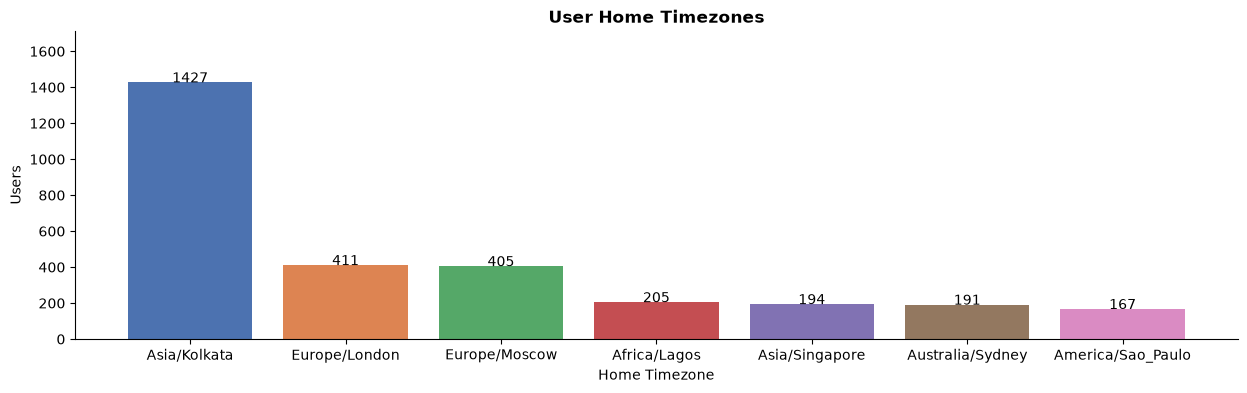

In [15]:
fig, ax = plt.subplots(figsize=(15, 4))
counts = df['user_home_tz'].value_counts()
bars = ax.bar(counts.index, counts.values, color=C[:len(counts)])
ax.set_xlabel('Home Timezone'); ax.set_ylabel('Users')
ax.set_title('User Home Timezones', fontweight='bold')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.15, str(int(b.get_height())), ha='center', fontsize=10)
ax.set_ylim(0, counts.max()*1.2)
ax.spines[['top','right']].set_visible(False)
plt.show()

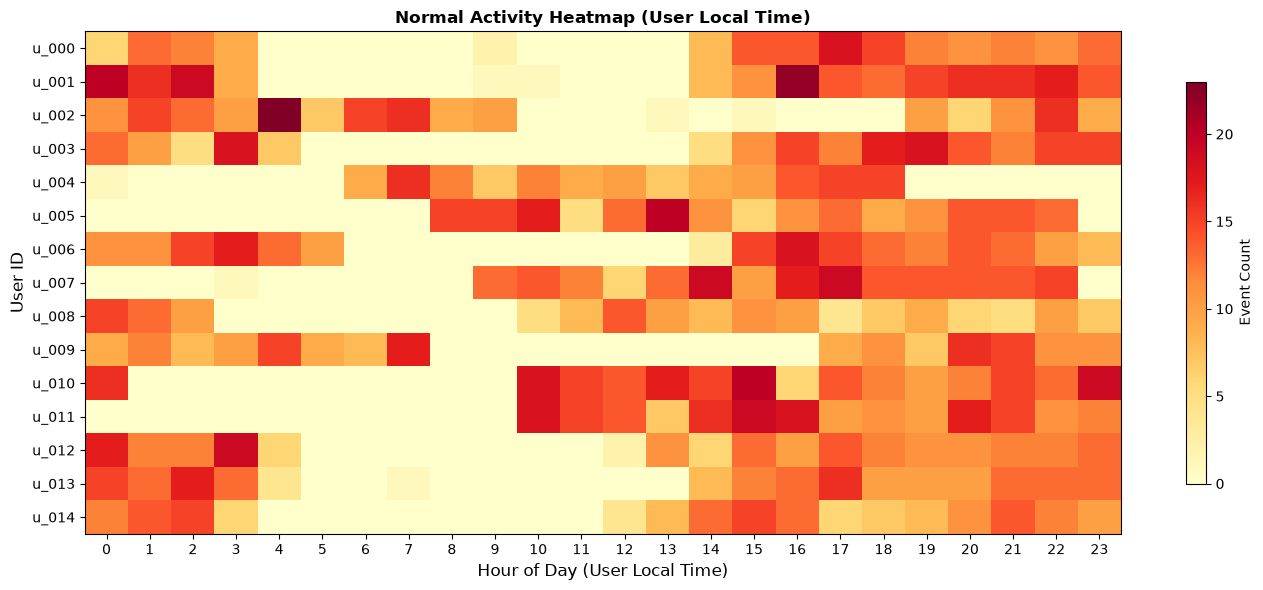

In [16]:
# Normal active hours per user (in their local time)
user_hours = df[~df['is_anomalous_ground_truth']].groupby('user_id')['user_local_hour'].apply(list)
all_users = sorted(df['user_id'].unique())
hours_range = list(range(24))
heat = pd.DataFrame(0, index=all_users, columns=hours_range)
for u in all_users:
    for h in user_hours.get(u, []):
        heat.loc[u, h] += 1

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heat.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')
ax.set_xlabel('Hour of Day (User Local Time)', fontsize=12)
ax.set_ylabel('User ID', fontsize=12)
ax.set_title('Normal Activity Heatmap (User Local Time)', fontweight='bold')
ax.set_xticks(range(24))
ax.set_yticks(range(len(all_users)))
ax.set_yticklabels(all_users)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Event Count')
plt.tight_layout(); plt.show()

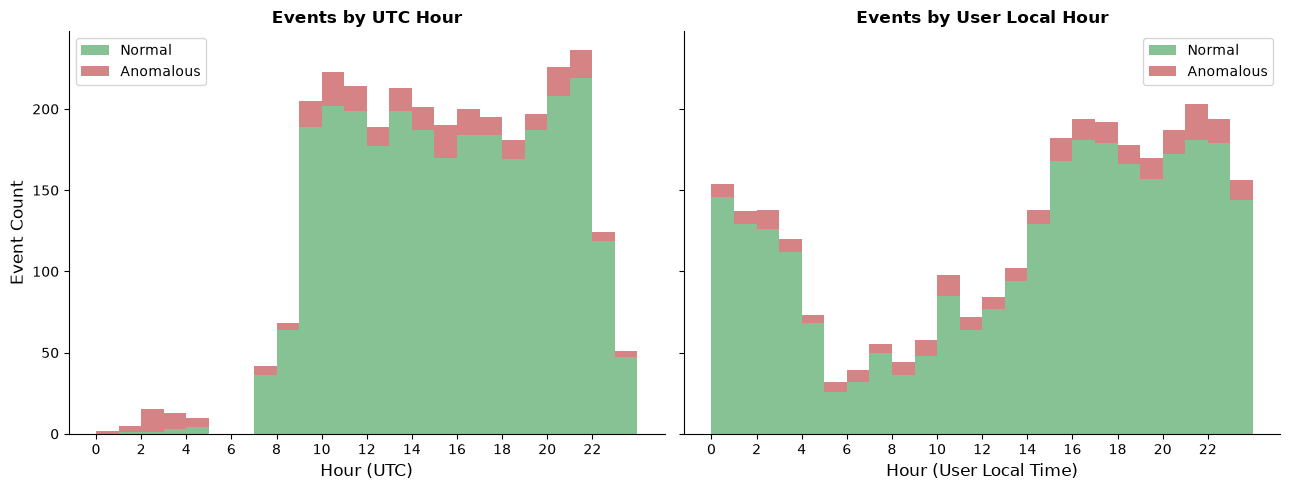

Notice: anomalies cluster differently in local time vs UTC. Timezone normalization matters! Saharsh ko koi batao Time matters!!


In [17]:
# Compare: UTC hour vs User Local hour
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
anom_df = df[df['is_anomalous_ground_truth']]
normal_df = df[~df['is_anomalous_ground_truth']]
ax1.hist([normal_df['hour'], anom_df['hour']], bins=24, range=(0,24),
         label=['Normal', 'Anomalous'], color=['#55A868', '#C44E52'], alpha=0.7, stacked=True)
ax1.set_xlabel('Hour (UTC)', fontsize=12); ax1.set_ylabel('Event Count', fontsize=12)
ax1.set_title('Events by UTC Hour', fontweight='bold')
ax1.set_xticks(range(0,24,2)); ax1.legend(); ax1.spines[['top','right']].set_visible(False)
ax2.hist([normal_df['user_local_hour'], anom_df['user_local_hour']], bins=24, range=(0,24),
         label=['Normal', 'Anomalous'], color=['#55A868', '#C44E52'], alpha=0.7, stacked=True)
ax2.set_xlabel('Hour (User Local Time)', fontsize=12)
ax2.set_title('Events by User Local Hour', fontweight='bold')
ax2.set_xticks(range(0,24,2)); ax2.legend(); ax2.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print('Notice: anomalies cluster differently in local time vs UTC. Timezone normalization matters! Saharsh ko koi batao Time matters!!')

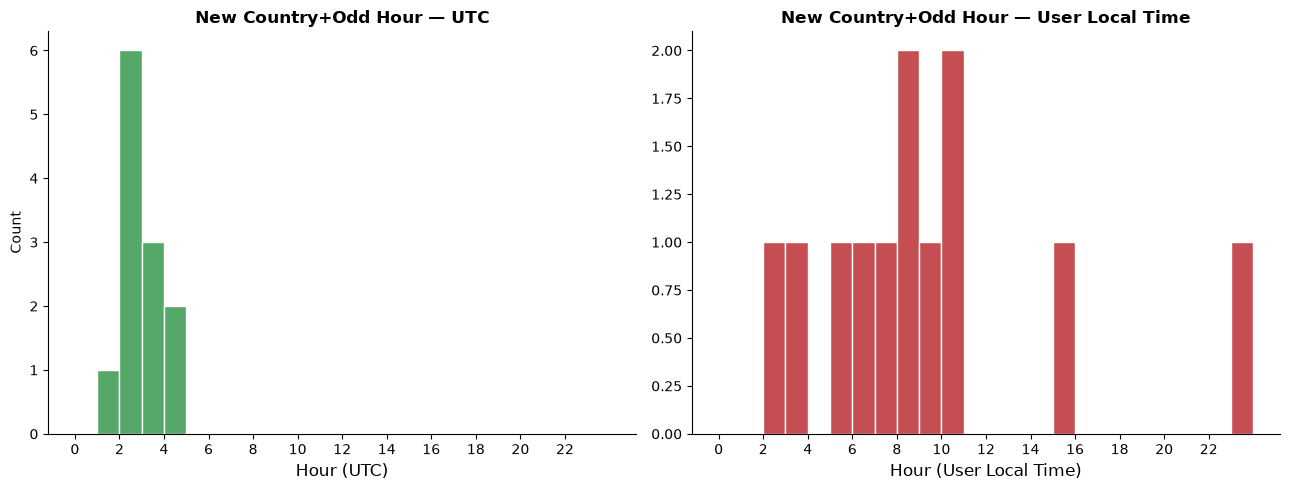

In UTC these look random. In user local time, they cluster during sleeping hours!


In [18]:
# new_country_odd_hour: local hour triggers
odd = df[df['anomaly_type'] == 'new_country_odd_hour']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(odd['hour'], bins=24, range=(0,24), color=C[2], edgecolor='white')
axes[0].set_xlabel('Hour (UTC)', fontsize=12); axes[0].set_ylabel('Count')
axes[0].set_title('New Country+Odd Hour — UTC', fontweight='bold')
axes[0].set_xticks(range(0,24,2)); axes[0].spines[['top','right']].set_visible(False)
axes[1].hist(odd['user_local_hour'], bins=24, range=(0,24), color=C[3], edgecolor='white')
axes[1].set_xlabel('Hour (User Local Time)', fontsize=12)
axes[1].set_title('New Country+Odd Hour — User Local Time', fontweight='bold')
axes[1].set_xticks(range(0,24,2)); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print('In UTC these look random. In user local time, they cluster during sleeping hours!')

## Summary
- **3,000 records**, 15 users, 9 activity types, 10 cities across 8 countries
- **8.4% anomalous** (251 records) with 5 anomaly scenarios
- **117 impossible travel events** (was 52 — missed ones now correctly tagged)
- **Realistic noise added:** 38% of VPN events are legitimate, 34% of login failures are normal typos
- **Fixed bugs:** 0 IP-geo conflicts, correct speed calculations, balanced activity distributions
- **Timezone-aware:** `user_home_tz` + `user_local_hour` fields for per-user local time profiling
